# Moulins and concentrated drainage

In the [previous tutorial](02-channels.ipynb) we explored how a subglacial drainage system responds to uniform basal melt.
In Greenland, however, most water reaches the bed through **moulins** — vertical shafts formed when supraglacial lakes drain through hydrofracture or when surface streams pour into crevasses.

A single moulin can deliver tens of cubic metres per second to a point on the bed, compared to the millimetres-per-year of uniform basal melt.
This concentrated input dramatically restructures the drainage:

* **Few moulins** → strong trunk channels, high pressure between channels
* **Many moulins** → denser channel network, more uniform (lower) pressure

In this tutorial we will:

1. Load the steady-state from the previous tutorial as a warm start.
2. Place moulins at specified locations and set their discharge.
3. Run to steady state and visualise the resulting channel network and $N(x)$ profile.
4. Compare 1, 10, and 100 moulins to see how moulin density controls drainage efficiency.

## Setup

We use the same geometry and model construction as before.
The only difference is how we define the melt-rate field: instead of a uniform scalar, we construct a sum of Gaussian blobs centred on the moulin locations.

The total water input is kept constant at 90 m³/s (equivalent to a moderate-melt Greenland summer distributed over the glacier area), and this volume is split equally among the moulins.

In [5]:
import firedrake as fd
import numpy as np
import matplotlib.pyplot as plt

from hydropack.models.subglacialhydrology import SubglacialHydrologyModel
from hydropack.constants import ice_density, water_density, gravity

# ── Same geometry as Tutorial 01 ──
Lx, Ly = 20e3, 5e3
nx, ny = 40, 10

mesh = fd.RectangleMesh(nx, ny, Lx, Ly)
Q = fd.FunctionSpace(mesh, "CG", 1)
CR = fd.FunctionSpace(mesh, "CR", 1)
x, y = fd.SpatialCoordinate(mesh)

surface = fd.interpolate(6 * (fd.sqrt(x + 5000) - fd.sqrt(5000.0)) + 1, Q)
bed = fd.interpolate(fd.Constant(0.0), Q)
H = surface - bed

p_i = fd.interpolate(fd.Constant(ice_density * gravity) * H, Q)
phi_m = fd.interpolate(fd.Constant(water_density * gravity) * bed, Q)
phi_0 = fd.interpolate(p_i + phi_m, Q)
u_b = fd.Function(Q).interpolate(fd.Constant(1e-6))
bc = fd.DirichletBC(Q, phi_m, 1)

# Background uniform melt rate
A1_RATE = 7.93e-11  # m/s (low uniform background)

## Representing moulins as Gaussian blobs

A moulin delivers discharge $Q_m$ (m³/s) at a single point $(x_m, y_m)$.
On a finite-element mesh we cannot represent a true delta function, so we spread each moulin into a normalised Gaussian blob with half-width $\sigma$:

$$m_{\text{moulin}}(x, y) = \frac{Q_m}{\int G\, dA} \sum_j \exp\!\left(-\frac{(x - x_j)^2 + (y - y_j)^2}{2\sigma^2}\right)$$

The total recharge field is the background uniform melt rate plus the moulin contributions.

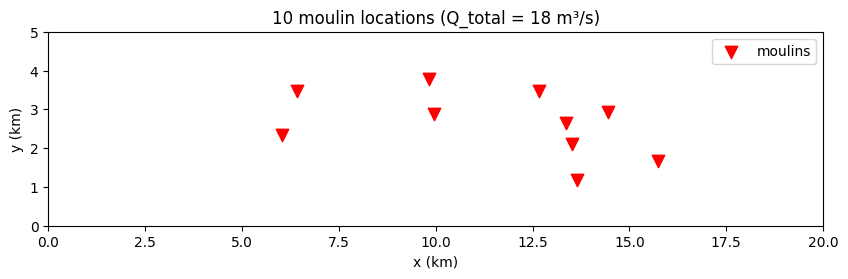

In [6]:
MOULIN_SIGMA = 1000.0  # m (half-width; must be ≥ 1 cell width)
Q_TOTAL = 18          # m³/s total moulin discharge (scaled for 20 km domain)

def gaussian_blobs(mesh, points, sigma=MOULIN_SIGMA):
    """Normalised sum of Gaussians centred at *points*, integrating to 1."""
    U = fd.FunctionSpace(mesh, "CG", 1)
    x, y = fd.SpatialCoordinate(mesh)
    g = sum(fd.exp(-((x - xi)**2 + (y - yi)**2) / (2 * sigma**2))
            for xi, yi in points)
    mass = fd.assemble(g * fd.dx)
    return fd.interpolate(g / (mass + 1e-30), U)


def place_moulins(n_moulins, Lx, Ly, seed=42):
    """Random moulin positions within the glacier interior."""
    rng = np.random.default_rng(seed)
    xs = rng.uniform(5e3, 0.8 * Lx, n_moulins)   # avoid terminus and divide
    ys = rng.uniform(1e3, Ly - 1e3, n_moulins)
    return list(zip(xs, ys))


def build_recharge(mesh, moulin_pts, Q_total=Q_TOTAL, background=A1_RATE):
    """Total recharge = background + moulin blobs."""
    U = fd.FunctionSpace(mesh, "CG", 1)
    blob = gaussian_blobs(mesh, moulin_pts)
    return fd.Function(U).interpolate(
        fd.Constant(background) + fd.Constant(Q_total) * blob
    )


# Visualise moulin placement for 10 moulins
pts_10 = place_moulins(10, Lx, Ly)
fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter([p[0]/1e3 for p in pts_10], [p[1]/1e3 for p in pts_10],
           s=80, c="red", marker="v", zorder=5, label="moulins")
ax.set_xlim(0, 20)
ax.set_ylim(0, 5)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title(f"{len(pts_10)} moulin locations (Q_total = {Q_TOTAL} m³/s)")
ax.legend()
ax.set_aspect("equal");

## Running with moulins

We compare three configurations — 1, 10, and 100 moulins — all delivering the same total discharge.
With a single moulin, all 90 m³/s enters at one point, creating a massive trunk channel.
With 100 moulins, each delivers only 0.9 m³/s, spreading the input more evenly.

In [7]:
def advance_to_steady(model, dt, *, rel_tol=5e-4,
                      max_steps=5000, check_every=6):
    """Run the model to steady state (melt rate already set on model.m)."""
    phi_prev = fd.Function(model.U).interpolate(model.phi)
    N_prev = fd.Function(model.U).interpolate(model.N)
    h_prev = fd.Function(model.U).interpolate(model.h)
    S_prev = fd.Function(model.CR).interpolate(model.S)

    for k in range(1, max_steps + 1):
        model.step(dt)
        if k % check_every == 0:
            model.update_phi()
            rphi = float(fd.norm(model.phi - phi_prev) / (fd.norm(model.phi) + 1e-30))
            rN = float(fd.norm(model.N - N_prev) / (fd.norm(model.N) + 1e-30))
            rh = float(fd.norm(model.h - h_prev) / (fd.norm(model.h) + 1e-30))
            rS = float(fd.norm(model.S - S_prev) / (fd.norm(model.S) + 1e-30))
            phi_prev.assign(model.phi); N_prev.assign(model.N)
            h_prev.assign(model.h); S_prev.assign(model.S)
            sim_days = k * dt / 86400
            if k % (check_every * 50) == 0:
                print(f"  day {sim_days:.0f}: rphi={rphi:.2e} rN={rN:.2e} rh={rh:.2e} rS={rS:.2e}")
            if rphi < rel_tol and rN < rel_tol and rh < rel_tol and rS < rel_tol:
                print(f"  Converged at day {sim_days:.0f} (step {k})")
                return k
    print(f"  WARNING: did not converge in {max_steps} steps")
    return max_steps


def width_averaged_Nx(model, Lx=20e3, nbins=40):
    """Compute width-averaged effective pressure N(x)."""
    coords = model.mesh.coordinates.dat.data_ro
    xv = coords[:, 0]
    Nvals = model.N.dat.data_ro
    bins = np.linspace(0, Lx, nbins + 1)
    idx = np.digitize(xv, bins) - 1
    Nx = np.zeros(nbins); count = np.zeros(nbins, dtype=int)
    for i, val in zip(idx, Nvals):
        if 0 <= i < nbins:
            Nx[i] += val; count[i] += 1
    mask = count > 0
    Nx[mask] /= count[mask]
    return 0.5 * (bins[:-1] + bins[1:]), Nx


# Moulin cases need shorter dt than uniform melt — concentrated sources
# create steep local gradients that require smaller Newton steps.
dt = 3600        # 1-hour timestep throughout

moulin_configs = {
    "1 moulin":    1,
    "50 moulins": 50,
}

moulin_results = {}
moulin_models = {}

for label, n_m in moulin_configs.items():
    print(f"\n=== {label} (Q_per_moulin = {Q_TOTAL/n_m:.1f} m³/s) ===")

    pts = place_moulins(n_m, Lx, Ly)
    blob = gaussian_blobs(mesh, pts)

    h_init = fd.interpolate(fd.Constant(0.01), Q)
    S_init = fd.interpolate(fd.Constant(0.001), CR)
    phi_init = fd.Function(Q).interpolate(phi_0)

    model = SubglacialHydrologyModel(
        mesh,
        thickness=H, bed=bed, sliding_speed=u_b,
        melt_rate=fd.Function(Q).interpolate(fd.Constant(A1_RATE)),
        phi_init=phi_init, h_init=h_init, S_init=S_init,
        phi_m=phi_m, p_i=p_i, phi_0=phi_0,
        dirichlet_bcs=[bc],
        englacial_void_ratio=1e-4,
    )

    # Gradually ramp moulin recharge
    print("  Ramping moulin input...")
    for frac in [0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]:
        model.m.interpolate(fd.Constant(A1_RATE) + fd.Constant(frac * Q_TOTAL) * blob)
        for _ in range(50):
            model.step(dt)
        model.update_phi()

    # Set final melt rate and run to steady state
    model.m.interpolate(fd.Constant(A1_RATE) + fd.Constant(Q_TOTAL) * blob)
    advance_to_steady(model, dt)
    model.update_phi()

    xc, Nx = width_averaged_Nx(model)
    moulin_results[label] = (xc, Nx, pts)
    moulin_models[label] = model


=== 1 moulin (Q_per_moulin = 18.0 m³/s) ===
  Ramping moulin input...


/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


  day 12: rphi=5.96e-03 rN=3.53e-02 rh=2.43e-03 rS=1.68e-02
  day 25: rphi=3.52e-03 rN=9.50e-03 rh=2.88e-03 rS=1.05e-02
  day 38: rphi=1.76e-03 rN=3.30e-03 rh=2.81e-03 rS=8.00e-03
  day 50: rphi=1.00e-03 rN=1.75e-03 rh=2.04e-03 rS=6.90e-03
  day 62: rphi=8.47e-04 rN=1.59e-03 rh=1.14e-03 rS=6.79e-03
  day 75: rphi=2.82e-04 rN=5.60e-04 rh=7.04e-04 rS=7.21e-03
  day 88: rphi=3.82e-04 rN=7.45e-04 rh=4.78e-04 rS=7.45e-03
  day 100: rphi=6.80e-04 rN=1.24e-03 rh=7.01e-04 rS=7.24e-03
  day 112: rphi=9.08e-04 rN=1.50e-03 rh=1.12e-03 rS=6.74e-03
  day 125: rphi=1.17e-03 rN=1.72e-03 rh=1.60e-03 rS=6.13e-03
  day 138: rphi=1.38e-03 rN=1.75e-03 rh=2.06e-03 rS=5.28e-03
  day 150: rphi=1.25e-03 rN=1.39e-03 rh=2.11e-03 rS=4.02e-03
  day 162: rphi=1.03e-03 rN=1.03e-03 rh=1.72e-03 rS=2.92e-03
  day 175: rphi=1.16e-03 rN=1.08e-03 rh=1.16e-03 rS=2.25e-03
  day 188: rphi=4.49e-04 rN=3.88e-04 rh=8.78e-04 rS=1.59e-03
  day 200: rphi=3.95e-04 rN=3.35e-04 rh=5.47e-04 rS=1.35e-03

=== 50 moulins (Q_per_moulin =

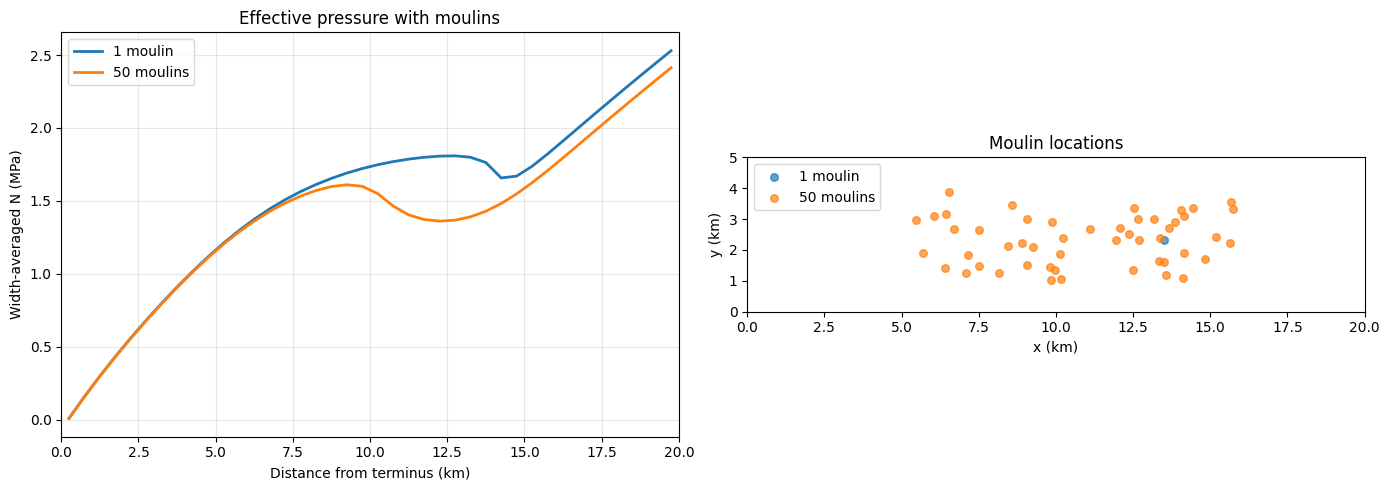

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: N(x) profiles
ax = axes[0]
for label, (xc, Nx, pts) in moulin_results.items():
    ax.plot(xc / 1e3, Nx / 1e6, lw=2, label=label)
ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Width-averaged N (MPa)")
ax.set_title("Effective pressure with moulins")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)

# Right: moulin locations
ax = axes[1]
for label, (xc, Nx, pts) in moulin_results.items():
    ax.scatter([p[0]/1e3 for p in pts], [p[1]/1e3 for p in pts],
               s=30, label=label, alpha=0.7)
ax.set_xlim(0, 20)
ax.set_ylim(0, 5)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Moulin locations")
ax.legend()
ax.set_aspect("equal")

fig.tight_layout();

### Channel networks with different moulin densities

The channel structure is what really differs between the cases.
With 1 moulin, a single massive trunk channel forms.
With 100 moulins, a dense dendritic network covers the lower glacier.

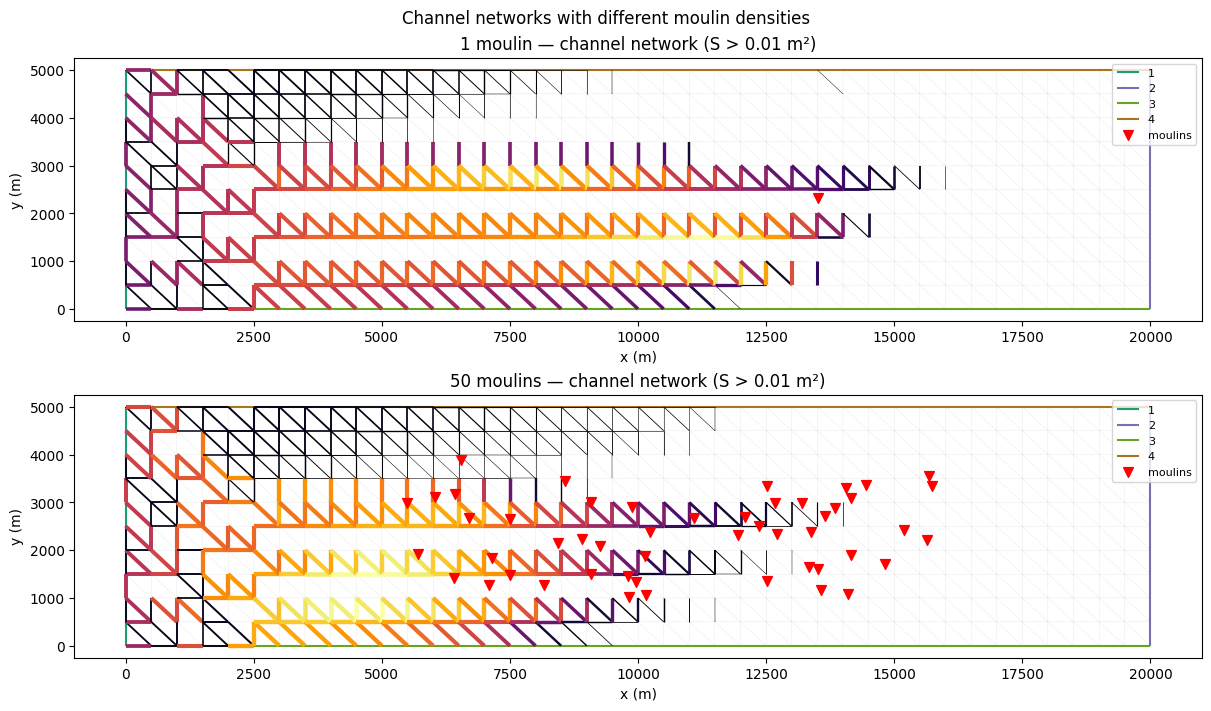

In [9]:
import hydropack.plot as hplot

n_cases = len(moulin_models)
fig, axes = plt.subplots(n_cases, 1, figsize=(12, 3.5 * n_cases),
                          constrained_layout=True, squeeze=False)

for ax, (label, mdl) in zip(axes.flat, moulin_models.items()):
    pts = moulin_results[label][2]

    # Mesh background
    fd.triplot(mdl.mesh, axes=ax, interior_kw={"linewidth": 0.1, "alpha": 0.15})

    # Channel network
    hplot.tripcolor_cr(mdl.S, axes=ax, cmap="inferno", threshold=0.01, lw_scale=3.0)

    # Moulin locations
    ax.scatter([p[0] for p in pts], [p[1] for p in pts],
               s=50, c="red", marker="v", zorder=10, label="moulins")

    ax.set_title(f"{label} — channel network (S > 0.01 m²)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(fontsize=8, loc="upper right")


## Conclusion

With a single moulin, the drainage system develops a strong trunk channel that efficiently evacuates water near the moulin, creating a corridor of low effective pressure.
Away from the channel, the sheet maintains higher pressure. 

As the number of moulins increases, the drainage network becomes denser and the width-averaged $N(x)$ profile becomes smoother and lower.
With 100 moulins, the system approaches the behaviour of a uniformly-forced glacier, but with channels carrying most of the discharge.

This moulin-density dependence is one of the key controls on Greenland ice dynamics:
outlet glaciers with many closely-spaced moulins (e.g., near the equilibrium line) tend to develop efficient channel networks that stabilise sliding, while glaciers with sparse mouliins maintain high-pressure distributed drainage that favours faster sliding.

### Next steps

**Diurnal forcing**: Modulate moulin discharge on a 24-hour cycle and observe the phase lag between forcing and effective-pressure response.

**Seasonal forcing**: Apply a degree-day melt model to study the spring speed-up and autumn channel collapse.

**Custom physics**: Swap the default Nye closure law for an alternative (e.g., Schoof 2010) by passing a custom `sheet_closure` function to `SubglacialHydrologyModel`.